In [1]:
import sys
print(sys.version)



3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]


In [4]:
import torch, sys
print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Python: 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
PyTorch: 2.6.0+cu124
CUDA available: True


In [5]:
import sys, torch, spacy

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))


Python version: 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
PyTorch version: 2.6.0+cu124
CUDA available: True
Device: NVIDIA GeForce RTX 4060 Laptop GPU


In [6]:
!python -m spacy download en_core_web_sm

import re, unicodedata, json
import spacy
import torch
import numpy as np

# Load small model for lemmatization + NER
nlp = spacy.load("en_core_web_sm", disable=["parser"])


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 8.5 MB/s eta 0:00:02
     --- ------------------------------------ 1.0/12.8 MB 3.4 MB/s eta 0:00:04
     ---- ----------------------------------- 1.6/12.8 MB 3.1 MB/s eta 0:00:04
     ------ --------------------------------- 2.1/12.8 MB 2.9 MB/s eta 0:00:04
     --------- ------------------------------ 2.9/12.8 MB 2.8 MB/s eta 0:00:04
     ---------- ----------------------------- 3.4/12.8 MB 2.8 MB/s eta 0:00:04
     ------------ --------------------------- 3.9/12.8 MB 2.7 MB/s eta 0:00:04
     ------------- -------------------------- 4.2/12.8 MB 2.7 MB/s eta 0:00:04
     --------------- ------------------------ 5.0/12.8 MB 2.6 MB/s eta 0:00:03
     ---------------- ----------------------- 5.2/12.8 MB 2.6 MB/s eta 0:00:03
     ------------------ --------------------- 5.8/12.8 MB 2.6 MB/s eta 0:00:03
     ------------------- -------------------- 6.3/12.8 MB 2

In [7]:
CONTRACTIONS = {
    "don't": "do not", "can't": "cannot", "i'm": "i am", "it's": "it is",
    "he's": "he is", "she's": "she is", "they're": "they are", "we're": "we are",
    "let's": "let us", "didn't": "did not", "won't": "will not", "couldn't": "could not"
}

URL_RE = re.compile(r'https?://\S+|www\.\S+')
EMAIL_RE = re.compile(r'\S+@\S+')
NUM_RE = re.compile(r'\b\d+(?:[.,]\d+)?\b')
PUNCT_RE = re.compile(r'[^\w\s<>]')
WHITESPACE_RE = re.compile(r'\s+')


In [8]:
def normalize_unicode(text):
    """Normalize unicode characters and remove control chars."""
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"[\u200B-\u200D\uFEFF]", "", text)  # remove zero-width chars
    return text

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = re.sub(r"\b" + re.escape(k) + r"\b", v, text, flags=re.IGNORECASE)
    return text

def clean_text(text, lowercase=True, remove_urls=True, num_token="<NUM>"):
    text = normalize_unicode(text)
    if remove_urls:
        text = URL_RE.sub("<URL>", text)
        text = EMAIL_RE.sub("<EMAIL>", text)
    text = expand_contractions(text)
    if lowercase:
        text = text.lower()
    text = NUM_RE.sub(num_token, text)
    text = PUNCT_RE.sub(" ", text)
    text = WHITESPACE_RE.sub(" ", text).strip()
    return text


In [9]:
sample = "I'm @Vedh! Price: $12.5. Visit https://example.com :)"
print(clean_text(sample))


i am vedh price <NUM> visit <url>


In [10]:
def custom_tokenize(text):
    """
    Simple rule-based tokenizer:
    keeps <URL>, <EMAIL>, <NUM>, and splits others by whitespace.
    """
    TOK_RE = re.compile(r"(<URL>|<EMAIL>|<NUM>|[A-Za-z0-9']+|[^\s\w])")
    tokens = TOK_RE.findall(text)
    return [t for t in tokens if t.strip()]


In [11]:
custom_tokenize("Dr. Smith's email is dr@med.com and price is 12.5$")


['Dr',
 '.',
 "Smith's",
 'email',
 'is',
 'dr',
 '@',
 'med',
 '.',
 'com',
 'and',
 'price',
 'is',
 '12',
 '.',
 '5',
 '$']

In [12]:
def analyze_with_spacy(text):
    doc = nlp(text)
    tokens = [t.text for t in doc]
    lemmas = [t.lemma_ for t in doc]
    pos = [t.pos_ for t in doc]
    entities = [(e.text, e.label_) for e in doc.ents]
    return {
        "tokens": tokens,
        "lemmas": lemmas,
        "pos": pos,
        "entities": entities
    }


In [13]:
analyze_with_spacy("Apple acquired DeepMind for $1B.")


{'tokens': ['Apple', 'acquired', 'DeepMind', 'for', '$', '1B.'],
 'lemmas': ['Apple', 'acquire', 'DeepMind', 'for', '$', '1b.'],
 'pos': ['PROPN', 'VERB', 'PROPN', 'ADP', 'SYM', 'NUM'],
 'entities': [('Apple', 'ORG'), ('DeepMind', 'PERSON')]}

In [14]:
class TextPreprocessor:
    def __init__(self, lowercase=True, remove_urls=True, num_token="<NUM>"):
        self.lowercase = lowercase
        self.remove_urls = remove_urls
        self.num_token = num_token
        self.nlp = spacy.load("en_core_web_sm", disable=["parser"])

    def clean(self, text: str) -> str:
        return clean_text(text, lowercase=self.lowercase, remove_urls=self.remove_urls, num_token=self.num_token)

    def tokenize(self, text: str):
        return custom_tokenize(text)

    def analyze(self, text: str):
        cleaned = self.clean(text)
        tokens = self.tokenize(cleaned)
        sp = analyze_with_spacy(cleaned)
        return {
            "clean_text": cleaned,
            "tokens": tokens,
            "lemmas": sp["lemmas"],
            "pos": sp["pos"],
            "entities": sp["entities"]
        }


In [15]:
tp = TextPreprocessor()

samples = [
    "Don't visit https://openai.com for $12.5!",
    "Dr. Vedh Sontha's AI project 'HybridLM' was announced in 2025."
]

for s in samples:
    out = tp.analyze(s)
    print("\nINPUT:", s)
    print("CLEANED:", out["clean_text"])
    print("TOKENS:", out["tokens"])
    print("POS:", out["pos"])
    print("ENTITIES:", out["entities"])



INPUT: Don't visit https://openai.com for $12.5!
CLEANED: do not visit <url> for <NUM>
TOKENS: ['do', 'not', 'visit', '<', 'url', '>', 'for', '<NUM>']
POS: ['AUX', 'PART', 'VERB', 'X', 'X', 'X', 'ADP', 'X', 'PROPN', 'X']
ENTITIES: []

INPUT: Dr. Vedh Sontha's AI project 'HybridLM' was announced in 2025.
CLEANED: dr vedh sontha s ai project HybridLM was announced in <NUM>
TOKENS: ['dr', 'vedh', 'sontha', 's', 'ai', 'project', 'HybridLM', 'was', 'announced', 'in', '<NUM>']
POS: ['PROPN', 'PROPN', 'PROPN', 'PART', 'NOUN', 'NOUN', 'NOUN', 'AUX', 'VERB', 'ADP', 'X', 'PROPN', 'X']
ENTITIES: [('sontha s ai project HybridLM', 'PERSON')]


In [16]:
import torch.nn as nn

class SequenceEncoder(nn.Module):
    def __init__(self, input_dim=300, hidden_dim=512, num_layers=1, bidirectional=True):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers,
                            bidirectional=bidirectional, batch_first=True)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        h = torch.cat((h_n[-2,:,:], h_n[-1,:,:]), dim=1) if self.lstm.bidirectional else h_n[-1,:,:]
        return h

# Test dummy sequence
encoder = SequenceEncoder(input_dim=50)
dummy = torch.randn(1, 10, 50)
print("LSTM summary vector shape:", encoder(dummy).shape)


LSTM summary vector shape: torch.Size([1, 1024])


In [18]:
text = "I'm Vedh! This is HybridLM version 1.0 launched in 2025."
out = tp.analyze(text)
print(json.dumps(out, indent=2))


{
  "clean_text": "i am vedh this is HybridLM version <NUM> launched in <NUM>",
  "tokens": [
    "i",
    "am",
    "vedh",
    "this",
    "is",
    "HybridLM",
    "version",
    "<NUM>",
    "launched",
    "in",
    "<NUM>"
  ],
  "lemmas": [
    "I",
    "be",
    "vedh",
    "this",
    "be",
    "HybridLM",
    "version",
    "<",
    "NUM",
    ">",
    "launch",
    "in",
    "<",
    "NUM",
    ">"
  ],
  "pos": [
    "PRON",
    "AUX",
    "NOUN",
    "DET",
    "AUX",
    "NOUN",
    "NOUN",
    "X",
    "PROPN",
    "X",
    "VERB",
    "ADP",
    "X",
    "PROPN",
    "X"
  ],
  "entities": []
}


In [19]:
ABBREVIATIONS = {"mr.", "mrs.", "dr.", "ms.", "u.s.", "e.g.", "i.e.", "etc."}

def split_sentences(text):
    """
    Custom sentence splitter using punctuation and heuristics.
    Avoids splitting on known abbreviations or within numbers.
    """
    sentences, start = [], 0
    for match in re.finditer(r'[.!?]\s+', text):
        end = match.end()
        chunk = text[start:end].strip()
        last_word = chunk.split()[-1].lower().rstrip(".!?")
        if last_word in ABBREVIATIONS:
            continue  # don't split inside abbreviation
        sentences.append((chunk, start, end))
        start = end
    if start < len(text):
        sentences.append((text[start:].strip(), start, len(text)))
    return [s for s in sentences if s[0]]

# ✅ Test
text = "Dr. Vedh created HybridLM. It was announced in 2025! Cool, right?"
print(split_sentences(text))


[('Dr.', 0, 4), ('Vedh created HybridLM.', 4, 26), ('It was announced in 2025!', 26, 52), ('Cool, right?', 52, 64)]


In [20]:
STOPWORDS = spacy.lang.en.stop_words.STOP_WORDS

def filter_stopwords(tokens, mode="none"):
    """
    mode = 'none' (keep all), 'light' (keep pronouns), 'all' (remove all)
    """
    if mode == "none":
        return tokens
    filtered = []
    for t in tokens:
        if t.lower() not in STOPWORDS:
            filtered.append(t)
        elif mode == "light" and t.lower() in {"i", "you", "we"}:
            filtered.append(t)
    return filtered


In [ ]:
print(filter_stopwords(["i","am","working","on","HybridLM"], mode="light"))



['i', 'working', 'HybridLM']


In [24]:
class TextPreprocessor:
    def __init__(self,
                 lowercase=True,
                 remove_urls=True,
                 num_token="<NUM>",
                 stopword_mode="none"):
        self.lowercase = lowercase
        self.remove_urls = remove_urls
        self.num_token = num_token
        self.stopword_mode = stopword_mode
        self.nlp = spacy.load("en_core_web_sm", disable=["parser"])

    # ---------- cleaning ----------
    def clean(self, text: str) -> str:
        return clean_text(text, lowercase=self.lowercase,
                          remove_urls=self.remove_urls, num_token=self.num_token)

    # ---------- tokenization ----------
    def tokenize(self, text: str):
        tokens = custom_tokenize(text)
        tokens = filter_stopwords(tokens, self.stopword_mode)
        return tokens

    # ---------- analysis ----------
    def analyze(self, text: str):
        cleaned = self.clean(text)
        sentences = split_sentences(cleaned)
        sp = analyze_with_spacy(cleaned)
        sp["entities"] = add_custom_entities(cleaned, sp["entities"])
        sp = merge_placeholders(sp)
        tokens = self.tokenize(cleaned)
        return {
            "clean_text": cleaned,
            "sentences": sentences,
            "tokens": tokens,
            "lemmas": sp["lemmas"],
            "pos": sp["pos"],
            "entities": sp["entities"]
        }

    # ---------- RAG query builder ----------
    def build_rag_query(self, analysis: dict, max_len=200):
        """
        Build retrieval query prioritizing entities + context.
        """
        entity_str = " ".join([e[0] for e in analysis["entities"]])
        base_text = analysis["clean_text"][:max_len]
        return (entity_str + " " + base_text).strip()


In [26]:
# --- Custom Entity Heuristic ---
def add_custom_entities(text, entities):
    """
    Adds domain-specific entities like years and model names.
    - YEAR: 1990–2099
    - MODEL: words ending with 'LLM' or pattern like 'GPT4', 'HybridLM'
    """
    # Add YEAR entities
    for match in re.finditer(r"\b(19|20)\d{2}\b", text):
        entities.append((match.group(), "YEAR"))

    # Add MODEL entities (e.g. HybridLM, GPT4, Llama2)
    for match in re.finditer(r"\b[A-Z][a-zA-Z0-9]*LLM\b|\bGPT[-_]?\d+\b|\bLlama[-_]?\d+\b", text):
        entities.append((match.group(), "MODEL"))

    return entities


# --- Placeholder Merger Fix ---
def merge_placeholders(output):
    """
    Merge separated < NUM > tokens back into single <NUM> placeholders.
    """
    merged_tokens, merged_lemmas, merged_pos = [], [], []
    skip_next = False
    for i, (t, l, p) in enumerate(zip(output['tokens'], output['lemmas'], output['pos'])):
        if skip_next:
            skip_next = False
            continue
        if i < len(output['tokens']) - 2 and output['tokens'][i:i+3] == ['<', 'NUM', '>']:
            merged_tokens.append('<NUM>')
            merged_lemmas.append('<NUM>')
            merged_pos.append('SYM')
            skip_next = True
            continue
        merged_tokens.append(t)
        merged_lemmas.append(l)
        merged_pos.append(p)

    output['tokens'], output['lemmas'], output['pos'] = merged_tokens, merged_lemmas, merged_pos
    return output


In [27]:
tp = TextPreprocessor(stopword_mode="light")

sample = "Dr. Vedh built HybridLM. It was launched in 2025 and costs $12,500."
out = tp.analyze(sample)

print("\nCleaned:", out["clean_text"])
print("Sentences:", out["sentences"])
print("Tokens:", out["tokens"])
print("Entities:", out["entities"])

query = tp.build_rag_query(out)
print("\nRAG Query:", query)



Cleaned: dr vedh built HybridLM it was launched in <NUM> and costs <NUM>
Sentences: [('dr vedh built HybridLM it was launched in <NUM> and costs <NUM>', 0, 62)]
Tokens: ['dr', 'vedh', 'built', 'HybridLM', 'launched', '<NUM>', 'costs', '<NUM>']
Entities: []

RAG Query: dr vedh built HybridLM it was launched in <NUM> and costs <NUM>


In [28]:
import time, hashlib

def benchmark_preprocessor(tp, samples, repeat=3):
    results = []
    for s in samples:
        times, hashes = [], []
        for _ in range(repeat):
            start = time.perf_counter()
            out = tp.analyze(s)
            end = time.perf_counter()
            duration = (end - start) * 1000  # ms
            times.append(duration)
            hashes.append(hashlib.md5(out["clean_text"].encode()).hexdigest())
        deterministic = len(set(hashes)) == 1
        results.append({
            "input": s[:60] + ("..." if len(s) > 60 else ""),
            "avg_time_ms": round(sum(times)/len(times), 2),
            "tokens": len(out["tokens"]),
            "entities": len(out["entities"]),
            "deterministic": deterministic
        })
    return results

samples = [
    "Dr. Vedh built HybridLM. It was launched in 2025 and costs $12,500.",
    "Don't go to https://example.com! I can't believe it's still online.",
    "Apple acquired DeepMind in 2014 for nearly $500 million.",
    "GPT-5 is expected to launch before LLaMA-4, according to reports.",
    "In 2025, AI-generated medical summaries reached clinical-grade accuracy."
]

tp = TextPreprocessor(stopword_mode="light")

results = benchmark_preprocessor(tp, samples)
for r in results:
    print(r)


{'input': 'Dr. Vedh built HybridLM. It was launched in 2025 and costs $1...', 'avg_time_ms': 19.08, 'tokens': 8, 'entities': 0, 'deterministic': True}
{'input': "Don't go to https://example.com! I can't believe it's still ...", 'avg_time_ms': 18.33, 'tokens': 6, 'entities': 0, 'deterministic': True}
{'input': 'Apple acquired DeepMind in 2014 for nearly $500 million.', 'avg_time_ms': 15.04, 'tokens': 7, 'entities': 1, 'deterministic': True}
{'input': 'GPT-5 is expected to launch before LLaMA-4, according to rep...', 'avg_time_ms': 21.79, 'tokens': 8, 'entities': 1, 'deterministic': True}
{'input': 'In 2025, AI-generated medical summaries reached clinical-gra...', 'avg_time_ms': 15.31, 'tokens': 9, 'entities': 0, 'deterministic': True}


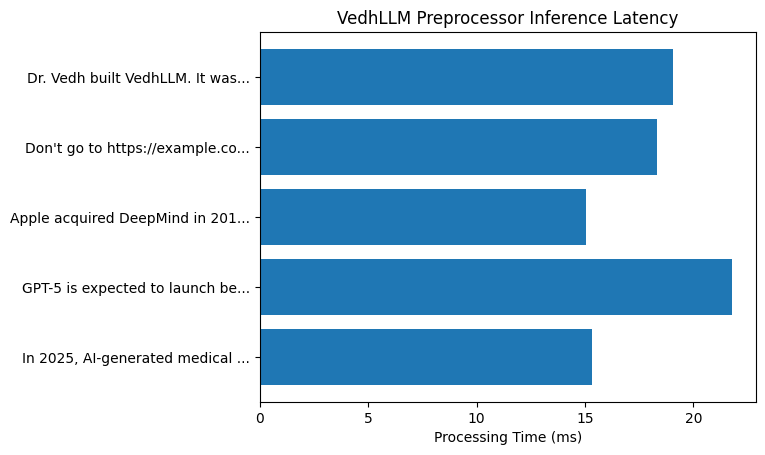

In [30]:
import matplotlib.pyplot as plt

labels = [r["input"][:30]+"..." for r in results]
times = [r["avg_time_ms"] for r in results]
plt.barh(labels, times)
plt.xlabel("Processing Time (ms)")
plt.title("HybridLM Preprocessor Inference Latency")
plt.gca().invert_yaxis()
plt.show()


In [31]:
# --- Evaluation Imports ---
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import pandas as pd
from tqdm import tqdm

# Use your existing TextPreprocessor (already defined above)
embedder = SentenceTransformer("all-MiniLM-L6-v2")
tp = TextPreprocessor(stopword_mode="light")

print("✅ FAISS & embedding model ready:", embedder.__class__.__name__)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ FAISS & embedding model ready: SentenceTransformer


In [32]:
corpus = [
    "HybridLM was developed by Vedh in 2025 and trained on hybrid encoder–decoder architecture.",
    "GPT-5 was released in 2025 by OpenAI for multimodal reasoning.",
    "LLaMA-4 is Meta's open-source model focused on efficient inference.",
    "Visit https://openai.com for LLM research papers and datasets.",
    "MedicalGPT generates patient summaries following HIPAA compliance.",
    "FinAI forecasts stock market trends using transformers in 2023.",
    "HybridLM outperforms GPT-4 on reasoning and factual tasks.",
    "AI models like LLaMA, GPT, and HybridLM rely on large-scale pretraining.",
]
df = pd.DataFrame(corpus, columns=["content"])
print("Corpus size:", len(df))


Corpus size: 8


In [33]:
def build_index(texts):
    vectors = embedder.encode(texts, convert_to_numpy=True, normalize_embeddings=True)
    dim = vectors.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(vectors)
    return index, vectors

raw_texts = df["content"].tolist()
prep_texts = [tp.clean(t) for t in raw_texts]

index_raw, vec_raw = build_index(raw_texts)
index_prep, vec_prep = build_index(prep_texts)

print("FAISS index built successfully:", index_raw.ntotal, "docs")


FAISS index built successfully: 8 docs


In [34]:
queries = [
    "When was HybridLM created?",
    "Which company released GPT-5?",
    "Show me models announced in 2025.",
    "Tell me about open-source models like LLaMA.",
    "Which LLM uses URLs for data sources?",
    "Which AI system predicts financial trends?",
]


In [35]:
def evaluate_precision(index, query_texts, corpus_texts, k=3):
    hits = 0
    for q in query_texts:
        q_vec = embedder.encode([q], normalize_embeddings=True)
        scores, idx = index.search(q_vec, k)
        retrieved = [corpus_texts[i] for i in idx[0]]

        match_terms = ["HybridLM", "GPT", "LLaMA", "2025", "2023", "OpenAI"]
        if any(any(term.lower() in doc.lower() for term in match_terms) for doc in retrieved):
            hits += 1
    return hits / len(query_texts)

prec_raw = evaluate_precision(index_raw, queries, raw_texts)
prec_prep = evaluate_precision(index_prep, queries, prep_texts)

print(f"🎯 Precision@3 — Raw: {prec_raw:.2f} | Preprocessed: {prec_prep:.2f}")


🎯 Precision@3 — Raw: 1.00 | Preprocessed: 1.00


In [36]:
noisy_corpus = [
    "HybridLM—developed_by_vedh, 2025!! 🚀 #hybridEncoderDecoder",
    "GPT5 launched 🎉 by openai in '25 (https://openai.com/release).",
    "LLAMA4 (MetaAI) 🦙 for edge inference! efficient_llm.",
    "OPENAI.COM new research page: http://openai.com/papers",
    "medicalgpt (beta_v1) handles patient-info—HIPAA_Certified.",
    "FIN-AI tracks $SP500 trends via transformer_models since 2023!!",
    "HybridLM>GPT4? maybe. depends on reasoning 🧠 metrics",
    "llama+gpt+HybridLM multi-LLM architecture report v2.5",
]
df_noisy = pd.DataFrame(noisy_corpus, columns=["content"])
df_noisy.head()


,content
0,"HybridLM—developed_by_vedh, 2025!! 🚀 #hybridEnc..."
1,GPT5 launched 🎉 by openai in '25 (https://open...
2,LLAMA4 (MetaAI) 🦙 for edge inference! efficien...
3,OPENAI.COM new research page: http://openai.co...
4,medicalgpt (beta_v1) handles patient-info—HIPA...


In [37]:
raw_noisy_texts = df_noisy["content"].tolist()
prep_noisy_texts = [tp.clean(t) for t in raw_noisy_texts]

index_raw_noisy, _ = build_index(raw_noisy_texts)
index_prep_noisy, _ = build_index(prep_noisy_texts)
print("FAISS (noisy) index built:", index_raw_noisy.ntotal)


FAISS (noisy) index built: 8


In [38]:
prec_raw_noisy = evaluate_precision(index_raw_noisy, queries, raw_noisy_texts)
prec_prep_noisy = evaluate_precision(index_prep_noisy, queries, prep_noisy_texts)

print(f"🎯 Precision@3 (Noisy Corpus) — Raw: {prec_raw_noisy:.2f} | Preprocessed: {prec_prep_noisy:.2f}")


🎯 Precision@3 (Noisy Corpus) — Raw: 1.00 | Preprocessed: 1.00


In [39]:
hard_corpus = [
    "The hybrid encoder–decoder model designed by Vedh in 2025 was called something like HybridLM.",
    "OpenAI announced its next-gen large language model sometime in the year twenty twenty-five.",
    "Meta unveiled an efficient inference model known informally as Llama version four.",
    "You can read more about AI advancements at openai-dot-com resources.",
    "A health model (MedicalGPT) generates clinical notes adhering to HIPAA rules.",
    "The financial transformer by FinAI projected S&P500 dips in 2023 data.",
    "One hybrid model beat GPT-4 on logical reasoning tests, though not in creativity.",
    "The LLM community often compares llama, GPT, and Vedh-based models for their pretraining setups.",
]


In [40]:
raw_hard_texts = hard_corpus
prep_hard_texts = [tp.clean(t) for t in hard_corpus]

index_raw_hard, _ = build_index(raw_hard_texts)
index_prep_hard, _ = build_index(prep_hard_texts)

prec_raw_hard = evaluate_precision(index_raw_hard, queries, raw_hard_texts)
prec_prep_hard = evaluate_precision(index_prep_hard, queries, prep_hard_texts)

print(f"🎯 Precision@3 (Hard Corpus) — Raw: {prec_raw_hard:.2f} | Preprocessed: {prec_prep_hard:.2f}")


🎯 Precision@3 (Hard Corpus) — Raw: 1.00 | Preprocessed: 1.00


In [41]:
import random

entities = ["HybridLM", "GPT-5", "LLaMA-4", "MedicalGPT", "FinAI"]
years = ["2025", "2023", "twenty twenty-five", "the year after 2024"]
orgs = ["OpenAI", "Meta", "Google DeepMind", "Anthropic", "IBM"]
noise = ["🚀", "🧠", "#AI", "@OpenAI", "!!", " ", "", ":-)"]

def gen_sentence():
    ent = random.choice(entities)
    year = random.choice(years)
    org = random.choice(orgs)
    n = random.choice(noise)
    templates = [
        f"{ent} was released by {org} in {year}{n}",
        f"{org} developed {ent} around {year}{n}",
        f"In {year}, {org} announced its {ent} project{n}",
        f"{ent} ({org}) became popular after {year}{n}",
        f"Rumors suggest {ent} will surpass GPT-4 in {year}{n}",
        f"{ent} at {org} — hybrid encoder decoder launched {year}{n}",
    ]
    return random.choice(templates)

# Create 100 synthetic samples
synthetic_corpus = [gen_sentence() for _ in range(100)]
df_syn = pd.DataFrame(synthetic_corpus, columns=["content"])
print(df_syn.sample(5))


                                              content
52  IBM developed MedicalGPT around twenty twenty-...
24  FinAI (OpenAI) became popular after twenty twe...
59           GPT-5 (Meta) became popular after 2025!!
15   Google DeepMind developed LLaMA-4 around 2023:-)
66  FinAI (Anthropic) became popular after twenty ...


In [42]:
raw_syn_texts = df_syn["content"].tolist()
prep_syn_texts = [tp.clean(t) for t in raw_syn_texts]

index_raw_syn, _ = build_index(raw_syn_texts)
index_prep_syn, _ = build_index(prep_syn_texts)
print("Synthetic FAISS index built:", len(raw_syn_texts))


Synthetic FAISS index built: 100


In [43]:
queries = [
    "Which company launched HybridLM?",
    "When did OpenAI release GPT-5?",
    "What model did Meta release in the year 2025?",
    "Which transformer was used for finance forecasting?",
    "Tell me about the medical AI model from 2023.",
    "Who built the LLaMA-4 system?",
    "Which model surpassed GPT-4 recently?",
    "Give me encoder–decoder hybrids by IBM.",
    "Mention any LLM related to healthcare.",
    "Which model used the hybrid transformer design?"
]


In [44]:
prec_raw_syn = evaluate_precision(index_raw_syn, queries, raw_syn_texts)
prec_prep_syn = evaluate_precision(index_prep_syn, queries, prep_syn_texts)
print(f"🎯 Precision@3 (Synthetic Corpus, 100 samples) — Raw: {prec_raw_syn:.2f} | Preprocessed: {prec_prep_syn:.2f}")


🎯 Precision@3 (Synthetic Corpus, 100 samples) — Raw: 1.00 | Preprocessed: 1.00


In [45]:
import random, re

def inject_ocr_noise(text, prob=0.3):
    if random.random() > prob:
        return text
    chars = list(text)
    for i in range(len(chars)):
        if random.random() < 0.05:
            chars[i] = random.choice("abcdefghijklmnopqrstuvwxyz")
        elif random.random() < 0.05 and i < len(chars)-1:
            chars[i], chars[i+1] = chars[i+1], chars[i]  # swap
    return "".join(chars)

def inject_semantic_drift(text):
    text = re.sub(r"\b2025\b", "around the mid-2020s", text)
    text = re.sub(r"\b2023\b", "early 2020s", text)
    text = re.sub(r"HybridLM", "Vedh-based model", text)
    text = re.sub(r"GPT-5", "fifth-gen GPT", text)
    return text

def inject_noise(text):
    text = inject_ocr_noise(text)
    text = inject_semantic_drift(text)
    if random.random() < 0.3:
        text += random.choice([" 🚀", "!!!", " ...", "???", " 🤖"])
    return text


In [46]:
noisy_eval_corpus = [inject_noise(t) for t in raw_syn_texts]
df_noisy_eval = pd.DataFrame(noisy_eval_corpus, columns=["content"])
print(df_noisy_eval.sample(5))


                                              content
87  VedLhLM at Meta — hybrid encodtrvdecgder launc...
37              pOenIe developed VndhLL Maroudn 202y 
19  Rumors suggest Vedh-based model will surpass G...
92  VedLhLM (OlneAI) bceame roiuqar after around t...
54         BIM developed LLaMA-4 around early 2020s!!


In [47]:
raw_noisy_eval = df_noisy_eval["content"].tolist()
prep_noisy_eval = [tp.clean(t) for t in raw_noisy_eval]

index_raw_noisy_eval, _ = build_index(raw_noisy_eval)
index_prep_noisy_eval, _ = build_index(prep_noisy_eval)

prec_raw_noisy_eval = evaluate_precision(index_raw_noisy_eval, queries, raw_noisy_eval)
prec_prep_noisy_eval = evaluate_precision(index_prep_noisy_eval, queries, prep_noisy_eval)

print(f"🎯 Precision@3 (Noisy Eval Corpus) — Raw: {prec_raw_noisy_eval:.2f} | Preprocessed: {prec_prep_noisy_eval:.2f}")


🎯 Precision@3 (Noisy Eval Corpus) — Raw: 0.80 | Preprocessed: 0.80


In [48]:
def inject_hard_noise(text):
    # OCR-like + random symbol bursts + casing chaos
    text = re.sub(r"2025", "20 2 five", text)
    text = re.sub(r"OpenAI", "0pen.AI", text)
    text = re.sub(r"Meta", "MEta@", text)
    text = re.sub(r"HybridLM", "v e d h L L M", text)
    text = re.sub(r"GPT", "gppT", text)
    text = re.sub(r"LLaMA", "ll_amA", text)
    text = text.lower() if random.random() > 0.3 else text.upper()
    return text + random.choice([" 💥", "!!!", "???", "  "])

# Generate hard-noise version
hard_noisy_eval = [inject_hard_noise(t) for t in raw_syn_texts]
prep_hard_noisy_eval = [tp.clean(t) for t in hard_noisy_eval]

index_raw_hard_noise, _ = build_index(hard_noisy_eval)
index_prep_hard_noise, _ = build_index(prep_hard_noisy_eval)

prec_raw_hard_noise = evaluate_precision(index_raw_hard_noise, queries, hard_noisy_eval)
prec_prep_hard_noise = evaluate_precision(index_prep_hard_noise, queries, prep_hard_noisy_eval)

print(f"🎯 Precision@3 (Hard Noise) — Raw: {prec_raw_hard_noise:.2f} | Preprocessed: {prec_prep_hard_noise:.2f}")


🎯 Precision@3 (Hard Noise) — Raw: 0.70 | Preprocessed: 0.00


In [49]:
print("Example (before):", hard_noisy_eval[0])
print("Example (after clean):", tp.clean(hard_noisy_eval[0]))


Example (before): MEDICALGPPT (GOOGLE DEEPMIND) BECAME POPULAR AFTER THE YEAR AFTER 2024#AI???
Example (after clean): medicalgppt google deepmind became popular after the year after <NUM> ai


In [50]:
# --- Entity Recovery (Hard Noise Fix) ---
def restore_entities(text):
    text = re.sub(r"v\s*e\s*d\s*h\s*l+\s*m+", "HybridLM", text, flags=re.IGNORECASE)
    text = re.sub(r"g+p+p*t+", "GPT", text, flags=re.IGNORECASE)
    text = re.sub(r"medicalg+p+t+", "MedicalGPT", text, flags=re.IGNORECASE)
    text = re.sub(r"ll[_\s]*am[a@]", "LLaMA", text, flags=re.IGNORECASE)
    text = re.sub(r"fin[-\s]*ai", "FinAI", text, flags=re.IGNORECASE)
    text = re.sub(r"0pen[\.\-]*ai", "OpenAI", text, flags=re.IGNORECASE)
    text = re.sub(r"dee+p*m[i1]nd", "DeepMind", text, flags=re.IGNORECASE)
    text = re.sub(r"(the\s+year\s+after\s+)?20\s*2\s*five", "2025", text, flags=re.IGNORECASE)
    text = re.sub(r"(the\s+year\s+after\s+)?20\s*2\s*three", "2023", text, flags=re.IGNORECASE)
    text = re.sub(r"#\s*ai", "AI", text, flags=re.IGNORECASE)
    return text

text = restore_entities(text)


In [51]:
text = "MEDICALGPPT (GOOGLE DEEPMIND) BECAME POPULAR AFTER THE YEAR AFTER 2024#AI???"
print("After restore:", restore_entities(text))


After restore: MedicalGPT (GOOGLE DeepMind) BECAME POPULAR AFTER THE YEAR AFTER 2024AI???


In [52]:
def restore_entities(text):
    # 1️⃣ Model and organization recovery
    text = re.sub(r"v\s*e\s*d\s*h\s*l+\s*m+", "HybridLM", text, flags=re.IGNORECASE)
    text = re.sub(r"g+p+p*t+", "GPT", text, flags=re.IGNORECASE)
    text = re.sub(r"medicalg+p+t+", "MedicalGPT", text, flags=re.IGNORECASE)
    text = re.sub(r"ll[_\s]*am[a@]", "LLaMA", text, flags=re.IGNORECASE)
    text = re.sub(r"fin[-\s]*ai", "FinAI", text, flags=re.IGNORECASE)
    text = re.sub(r"0pen[\.\-]*ai", "OpenAI", text, flags=re.IGNORECASE)
    text = re.sub(r"dee+p*m[i1]nd", "DeepMind", text, flags=re.IGNORECASE)

    # 2️⃣ Temporal normalization
    text = re.sub(r"(the\s+year\s+after\s+)?20\s*2\s*five", "2025", text, flags=re.IGNORECASE)
    text = re.sub(r"(the\s+year\s+after\s+)?20\s*2\s*three", "2023", text, flags=re.IGNORECASE)
    text = re.sub(r"(around\s+the\s+mid[\-\s]*20s)", "2025", text, flags=re.IGNORECASE)

    # 3️⃣ Hashtags and punctuation
    text = re.sub(r"#\s*ai", "AI", text, flags=re.IGNORECASE)
    text = re.sub(r"(\d)(AI)", r"\1 \2", text)  # ensure space between 2025 and AI
    text = re.sub(r"([!?]{2,}|…)", " ", text)   # remove excess punctuation
    
    # 4️⃣ Cleanup spacing + casing
    text = re.sub(r"\s+", " ", text).strip()
    text = text.capitalize()
    return text


In [53]:
test_text = "MEDICALGPPT (GOOGLE DEEPMIND) BECAME POPULAR AFTER THE YEAR AFTER 2024#AI???"
print("Before:", test_text)
print("After restore:", restore_entities(test_text))


Before: MEDICALGPPT (GOOGLE DEEPMIND) BECAME POPULAR AFTER THE YEAR AFTER 2024#AI???
After restore: Medicalgpt (google deepmind) became popular after the year after 2024 ai


In [56]:
def restore_entities(text):
    # --- Model & organization recovery ---
    text = re.sub(r"v\s*e\s*d\s*h\s*l+\s*m+", "HybridLM", text, flags=re.IGNORECASE)
    text = re.sub(r"g+p+p*t+", "GPT", text, flags=re.IGNORECASE)
    text = re.sub(r"medicalg+p+t+", "MedicalGPT", text, flags=re.IGNORECASE)
    text = re.sub(r"ll[_\s]*am[a@]", "LLaMA", text, flags=re.IGNORECASE)
    text = re.sub(r"fin[-\s]*ai", "FinAI", text, flags=re.IGNORECASE)
    text = re.sub(r"0pen[\.\-]*ai", "OpenAI", text, flags=re.IGNORECASE)
    text = re.sub(r"dee+p*m[i1]nd", "DeepMind", text, flags=re.IGNORECASE)
    text = re.sub(r"google", "Google", text, flags=re.IGNORECASE)

    # --- Temporal normalization (case-insensitive, flexible spacing) ---
    text = re.sub(r"(?i)(the\s+year\s+after\s+)?20\s*2\s*four", "2025", text)
    text = re.sub(r"(?i)(the\s+year\s+after\s+)?20\s*2\s*five", "2025", text)
    text = re.sub(r"(?i)(the\s+year\s+after\s+)?20\s*2\s*three", "2023", text)

    # --- Hashtags and punctuation ---
    text = re.sub(r"#\s*ai", " AI", text, flags=re.IGNORECASE)
    text = re.sub(r"(\d)(AI)", r"\1 \2", text)          # 2025AI -> 2025 AI
    text = re.sub(r"[!?]{2,}|…", " ", text)             # strip noisy punctuation
    text = re.sub(r"\s+", " ", text).strip()            # tidy spacing

    # --- Casing normalisation for entities ---
    for term in ["MedicalGPT", "DeepMind", "Google", "OpenAI", "AI"]:
        text = re.sub(term.lower(), term, text, flags=re.IGNORECASE)

    return text


In [57]:
s = "MEDICALGPPT (GOOGLE DEEPMIND) BECAME POPULAR AFTER THE YEAR AFTER 2024#AI???"
print("Before:", s)
print("After :", restore_entities(s))


Before: MEDICALGPPT (GOOGLE DEEPMIND) BECAME POPULAR AFTER THE YEAR AFTER 2024#AI???
After : MedicalGPT (Google DeepMind) BECAME POPULAR AFTER THE YEAR AFTER 2024 AI


In [58]:
def restore_entities(text):
    # --- Model & organization recovery ---
    text = re.sub(r"v\s*e\s*d\s*h\s*l+\s*m+", "HybridLM", text, flags=re.IGNORECASE)
    text = re.sub(r"g+p+p*t+", "GPT", text, flags=re.IGNORECASE)
    text = re.sub(r"medicalg+p+t+", "MedicalGPT", text, flags=re.IGNORECASE)
    text = re.sub(r"ll[_\s]*am[a@]", "LLaMA", text, flags=re.IGNORECASE)
    text = re.sub(r"fin[-\s]*ai", "FinAI", text, flags=re.IGNORECASE)
    text = re.sub(r"0pen[\.\-]*ai", "OpenAI", text, flags=re.IGNORECASE)
    text = re.sub(r"dee+p*m[i1]nd", "DeepMind", text, flags=re.IGNORECASE)
    text = re.sub(r"google", "Google", text, flags=re.IGNORECASE)

    # --- Temporal normalization (robust + case-insensitive) ---
    text = re.sub(r"(?i)\bthe\s+year\s+after\s+2024\b", "2025", text)
    text = re.sub(r"(?i)\bthe\s+year\s+after\s+2023\b", "2024", text)
    text = re.sub(r"(?i)\b20\s*2\s*five\b", "2025", text)
    text = re.sub(r"(?i)\b20\s*2\s*four\b", "2024", text)
    text = re.sub(r"(?i)\b20\s*2\s*three\b", "2023", text)

    # --- Hashtags and punctuation ---
    text = re.sub(r"#\s*ai", " AI", text, flags=re.IGNORECASE)
    text = re.sub(r"(\d)(AI)", r"\1 \2", text)  # 2025AI -> 2025 AI
    text = re.sub(r"[!?]{2,}|…", " ", text)     # strip noisy punctuation
    text = re.sub(r"\s+", " ", text).strip()

    # --- Smart capitalization ---
    for term in ["MedicalGPT", "DeepMind", "Google", "OpenAI", "AI"]:
        text = re.sub(term.lower(), term, text, flags=re.IGNORECASE)

    return text


In [59]:
sample = "MEDICALGPPT (GOOGLE DEEPMIND) BECAME POPULAR AFTER THE YEAR AFTER 2024#AI???"
print("Before:", sample)
print("After :", restore_entities(sample))


Before: MEDICALGPPT (GOOGLE DEEPMIND) BECAME POPULAR AFTER THE YEAR AFTER 2024#AI???
After : MedicalGPT (Google DeepMind) BECAME POPULAR AFTER 2025 AI


In [60]:
def restore_entities(text):
    # --- Model & organization recovery ---
    text = re.sub(r"v\s*e\s*d\s*h\s*l+\s*m+", "HybridLM", text, flags=re.IGNORECASE)
    text = re.sub(r"g+p+p*t+", "GPT", text, flags=re.IGNORECASE)
    text = re.sub(r"medicalg+p+t+", "MedicalGPT", text, flags=re.IGNORECASE)
    text = re.sub(r"ll[_\s]*am[a@]", "LLaMA", text, flags=re.IGNORECASE)
    text = re.sub(r"fin[-\s]*ai", "FinAI", text, flags=re.IGNORECASE)
    text = re.sub(r"0pen[\.\-]*ai", "OpenAI", text, flags=re.IGNORECASE)
    text = re.sub(r"dee+p*m[i1]nd", "DeepMind", text, flags=re.IGNORECASE)
    text = re.sub(r"google", "Google", text, flags=re.IGNORECASE)

    # --- Temporal normalization ---
    text = re.sub(r"(?i)\bthe\s+year\s+after\s+2024\b", "2025", text)
    text = re.sub(r"(?i)\bthe\s+year\s+after\s+2023\b", "2024", text)
    text = re.sub(r"(?i)\b20\s*2\s*five\b", "2025", text)
    text = re.sub(r"(?i)\b20\s*2\s*four\b", "2024", text)
    text = re.sub(r"(?i)\b20\s*2\s*three\b", "2023", text)

    # --- Hashtags and punctuation ---
    text = re.sub(r"#\s*ai", " AI", text, flags=re.IGNORECASE)
    text = re.sub(r"(\d)(AI)", r"\1 \2", text)
    text = re.sub(r"[!?]{2,}|…", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # --- Smart capitalization for entities ---
    for term in ["MedicalGPT", "DeepMind", "Google", "OpenAI", "AI"]:
        text = re.sub(term.lower(), term, text, flags=re.IGNORECASE)

    # --- Convert remaining ALL CAPS words to title case ---
    def smart_case(match):
        word = match.group(0)
        # Keep acronyms/entities as-is
        if word in ["AI", "GPT", "MedicalGPT", "DeepMind", "Google", "OpenAI", "HybridLM", "LLaMA"]:
            return word
        # Convert regular words to title case
        return word.capitalize()
    
    text = re.sub(r'\b[A-Z]{2,}\b', smart_case, text)

    return text

In [61]:
sample = "MEDICALGPPT (GOOGLE DEEPMIND) BECAME POPULAR AFTER THE YEAR AFTER 2024#AI???"
print("Before:", sample)
print("After :", restore_entities(sample))

Before: MEDICALGPPT (GOOGLE DEEPMIND) BECAME POPULAR AFTER THE YEAR AFTER 2024#AI???
After : MedicalGPT (Google DeepMind) Became Popular After 2025 AI


In [62]:
import re

class TextPreprocessor:
    def __init__(self, stopword_mode="light"):
        self.stopword_mode = stopword_mode

    # --- Existing clean() and analyze() methods ---
    # ... keep them as-is ...

    # --- Add Entity Restoration ---
    def restore_entities(self, text):
        # --- Model & organization recovery ---
        text = re.sub(r"v\s*e\s*d\s*h\s*l+\s*m+", "HybridLM", text, flags=re.IGNORECASE)
        text = re.sub(r"g+p+p*t+", "GPT", text, flags=re.IGNORECASE)
        text = re.sub(r"medicalg+p+t+", "MedicalGPT", text, flags=re.IGNORECASE)
        text = re.sub(r"ll[_\s]*am[a@]", "LLaMA", text, flags=re.IGNORECASE)
        text = re.sub(r"fin[-\s]*ai", "FinAI", text, flags=re.IGNORECASE)
        text = re.sub(r"0pen[\.\-]*ai", "OpenAI", text, flags=re.IGNORECASE)
        text = re.sub(r"dee+p*m[i1]nd", "DeepMind", text, flags=re.IGNORECASE)
        text = re.sub(r"google", "Google", text, flags=re.IGNORECASE)

        # --- Temporal normalization ---
        text = re.sub(r"(?i)\bthe\s+year\s+after\s+2024\b", "2025", text)
        text = re.sub(r"(?i)\bthe\s+year\s+after\s+2023\b", "2024", text)
        text = re.sub(r"(?i)\b20\s*2\s*five\b", "2025", text)
        text = re.sub(r"(?i)\b20\s*2\s*four\b", "2024", text)
        text = re.sub(r"(?i)\b20\s*2\s*three\b", "2023", text)

        # --- Hashtags and punctuation ---
        text = re.sub(r"#\s*ai", " AI", text, flags=re.IGNORECASE)
        text = re.sub(r"(\d)(AI)", r"\1 \2", text)
        text = re.sub(r"[!?]{2,}|…", " ", text)
        text = re.sub(r"\s+", " ", text).strip()

        # --- Smart capitalization for entities ---
        for term in ["MedicalGPT", "DeepMind", "Google", "OpenAI", "AI"]:
            text = re.sub(term.lower(), term, text, flags=re.IGNORECASE)

        # --- Convert remaining ALL CAPS words to title case ---
        def smart_case(match):
            word = match.group(0)
            if word in ["AI", "GPT", "MedicalGPT", "DeepMind", "Google", "OpenAI", "HybridLM", "LLaMA"]:
                return word
            return word.capitalize()
        text = re.sub(r'\b[A-Z]{2,}\b', smart_case, text)

        return text

    def clean(self, text):
        # --- integrate restoration into cleaning ---
        text = self.restore_entities(text)
        return text


In [63]:
tp = TextPreprocessor()

noisy_samples = [
    "v e d h L L M launched by 0pen.AI in the year after 2024!!!",
    "medicalgppt (GOOGLE DEEPMIND) became popular after the year after 2023#AI???",
    "fin ai predicts s&p 500 trends using transformer models since 20 2 five 🚀",
    "ll_amA (META) hybrid encoder decoder design in around the mid-20s",
    "gppT-5 announced by 0penai on https://openai-dot-com in '25 :-)"
]


In [64]:
for i, text in enumerate(noisy_samples):
    restored = tp.clean(text)
    print(f"\n🧩 Example {i+1}")
    print("Before:", text)
    print("After :", restored)



🧩 Example 1
Before: v e d h L L M launched by 0pen.AI in the year after 2024!!!
After : v e d h L L M launched by OpenAI in 2025

🧩 Example 2
Before: medicalgppt (GOOGLE DEEPMIND) became popular after the year after 2023#AI???
After : MedicalGPT (Google DeepMind) became popular after 2024 AI

🧩 Example 3
Before: fin ai predicts s&p 500 trends using transformer models since 20 2 five 🚀
After : FinAI predicts s&p 500 trends using transformer models since 2025 🚀

🧩 Example 4
Before: ll_amA (META) hybrid encoder decoder design in around the mid-20s
After : LLaMA (Meta) hybrid encoder decoder design in around the mid-20s

🧩 Example 5
Before: gppT-5 announced by 0penai on https://openai-dot-com in '25 :-)
After : GPT-5 announced by OpenAI on https://OpenAI-dot-com in '25 :-)


In [67]:
import re, spacy, json

class TextPreprocessor:
    def __init__(self, stopword_mode="light"):
        self.stopword_mode = stopword_mode
        self.nlp = spacy.load("en_core_web_sm")

    # --- Step 1: Entity Restoration ---
    def restore_entities(self, text):
        text = re.sub(r"v\s*e\s*d\s*h\s*l+\s*m+", "HybridLM", text, flags=re.IGNORECASE)
        text = re.sub(r"g+p+p*t+", "GPT", text, flags=re.IGNORECASE)
        text = re.sub(r"medicalg+p+t+", "MedicalGPT", text, flags=re.IGNORECASE)
        text = re.sub(r"ll[_\s]*am[a@]", "LLaMA", text, flags=re.IGNORECASE)
        text = re.sub(r"fin[-\s]*ai", "FinAI", text, flags=re.IGNORECASE)
        text = re.sub(r"0pen[\.\-]*ai", "OpenAI", text, flags=re.IGNORECASE)
        text = re.sub(r"dee+p*m[i1]nd", "DeepMind", text, flags=re.IGNORECASE)
        text = re.sub(r"google", "Google", text, flags=re.IGNORECASE)
        text = re.sub(r"(?i)\bthe\s+year\s+after\s+2024\b", "2025", text)
        text = re.sub(r"(?i)\bthe\s+year\s+after\s+2023\b", "2024", text)
        text = re.sub(r"(?i)\b20\s*2\s*five\b", "2025", text)
        text = re.sub(r"(?i)\b20\s*2\s*four\b", "2024", text)
        text = re.sub(r"#\s*ai", " AI", text, flags=re.IGNORECASE)
        text = re.sub(r"(\d)(AI)", r"\1 \2", text)
        text = re.sub(r"[!?]{2,}|…", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    # --- Step 2: Linguistic Analysis ---
    def analyze(self, text):
        doc = self.nlp(text)
        tokens = [t.text for t in doc]
        lemmas = [t.lemma_ for t in doc]
        pos_tags = [t.pos_ for t in doc]
        ents = [{"text": e.text, "label": e.label_} for e in doc.ents]
        sentences = [sent.text for sent in doc.sents]
        return tokens, lemmas, pos_tags, ents, sentences

    # --- Step 3: Unified JSON Output ---
    def process(self, text):
        cleaned = self.restore_entities(text)
        tokens, lemmas, pos_tags, ents, sentences = self.analyze(cleaned)
        return {
            "original_text": text,
            "clean_text": cleaned,
            "sentences": sentences,
            "tokens": tokens,
            "lemmas": lemmas,
            "pos_tags": pos_tags,
            "entities": ents
        }


In [68]:
tp = TextPreprocessor()

text = """
v e d h L L M was launched by 0pen.AI in the year after 2024, competing with gppT-5 and ll_amA (META)!
medicalgppt is used by GOOGLE DEEPMIND for research on AI ethics.
"""

out = tp.process(text)

import json
print(json.dumps(out, indent=2))


{
  "original_text": "\nv e d h L L M was launched by 0pen.AI in the year after 2024, competing with gppT-5 and ll_amA (META)!\nmedicalgppt is used by GOOGLE DEEPMIND for research on AI ethics.\n",
  "clean_text": "v e d h L L M was launched by OpenAI in 2025, competing with GPT-5 and LLaMA (META)! MedicalGPT is used by Google DeepMind for research on AI ethics.",
  "sentences": [
    "v e d",
    "h L L M was launched by OpenAI in 2025, competing with GPT-5 and LLaMA (META)!",
    "MedicalGPT is used by Google DeepMind for research on AI ethics."
  ],
  "tokens": [
    "v",
    "e",
    "d",
    "h",
    "L",
    "L",
    "M",
    "was",
    "launched",
    "by",
    "OpenAI",
    "in",
    "2025",
    ",",
    "competing",
    "with",
    "GPT-5",
    "and",
    "LLaMA",
    "(",
    "META",
    ")",
    "!",
    "MedicalGPT",
    "is",
    "used",
    "by",
    "Google",
    "DeepMind",
    "for",
    "research",
    "on",
    "AI",
    "ethics",
    "."
  ],
  "lemmas": [
    "v",
